# Preparando o ambiente do trabalho

### Mudança da fonte:

In [2]:
# Mudança de fonte das cédulas markdown:
from IPython.core.display import HTML

HTML('''
<style>
    /* Altera a fonte nas células Markdown */
    div.text_cell_render {
        font-family: 'Verdana', sans-serif;
        font-size: 15px;
        color: black;
    }
</style>
''')

### Importar bibliotecas:

In [72]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Definindo funções:

In [73]:
def carregar_imagem(caminho):
    img = Image.open(caminho)
    img = img.convert("L")
    return np.array(img)

def mostrar_imagem(img, titulo="Imagem"):
    plt.imshow(img, cmap='gray')
    plt.title(titulo)
    plt.axis('off')
    plt.show()

def salvar_imagem(img, nome_arquivo):
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img.astype(np.uint8))
    img.save(nome_arquivo)

def normalizar_kernel(kernel):
    return kernel / np.sum(kernel)

def normalizar_imagem(img):
    img_min = img.min()
    img_max = img.max()
    if img_max - img_min == 0:
        return img
    return ((img - img_min) / (img_max - img_min) * 255).astype(np.uint8)

# Tarefa 1:

### Abrir e salvar imagem:

In [74]:
def gerar_quadrados_bp(tamanho=512):
    img = np.zeros((tamanho, tamanho), dtype=np.uint8)
    metade = tamanho // 2

    img[0:metade, metade:tamanho] = 255
    img[metade:tamanho, 0:metade] = 255

    return img

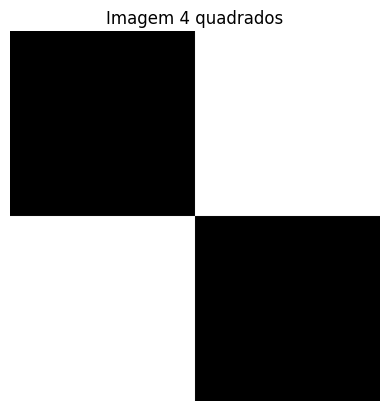

In [75]:
imagem1 = gerar_imagem_quadrados()
mostrar_imagem(imagem1, "Imagem 4 quadrados")
salvar_imagem(imagem1, "imagem_quadrados.png")

# Tarefa 2

## Aplicando a convolução

In [94]:
def criar_kernel_media(tamanho):
    kernel = np.ones((tamanho, tamanho))
    return normalizar_kernel(kernel)

In [87]:
def aplicar_convolucao(img, kernel, modo='reflect'):
    img = img.astype(np.float64)
    
    k = kernel.shape[0]
    pad = k // 2
    img_padded = np.pad(img, pad, mode=modo)
    resultado = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            regiao = img_padded[i:i+k, j:j+k]
            resultado[i, j] = np.sum(regiao * kernel)
    return resultado

In [89]:
kernel = criar_kernel_media(15)

## Resultados

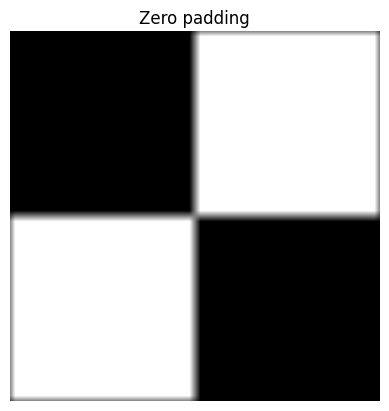

In [90]:
zero = aplicar_convolucao(imagem1, kernel, 'constant')
mostrar_imagem(zero, "Zero padding")

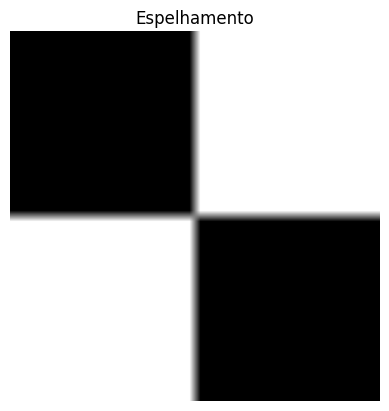

In [91]:
mirror = aplicar_convolucao(imagem1, kernel, 'reflect')
mostrar_imagem(mirror, "Espelhamento")

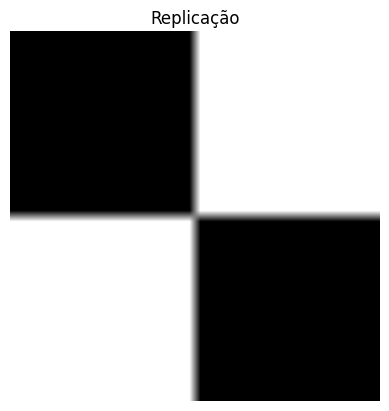

In [92]:
replicate = aplicar_convolucao(imagem1, kernel, 'edge')
mostrar_imagem(replicate, "Replicação")

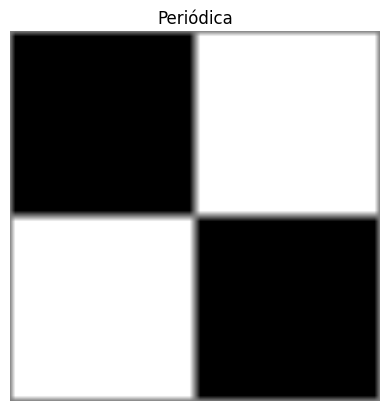

In [93]:
periodic = aplicar_convolucao(imagem1, kernel, 'wrap')
mostrar_imagem(periodic, "Periódica")

# Tarefa 3

### Carregar nova imagem

In [95]:
imagem_beatles = carregar_imagem("theBeatles.jpg")

### Resultado das convoluções

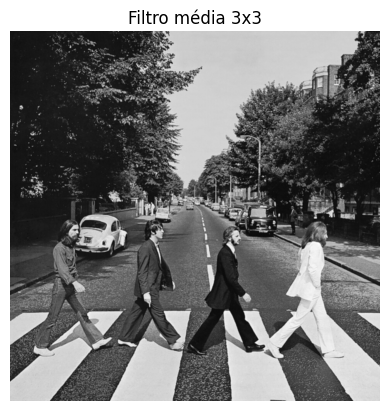

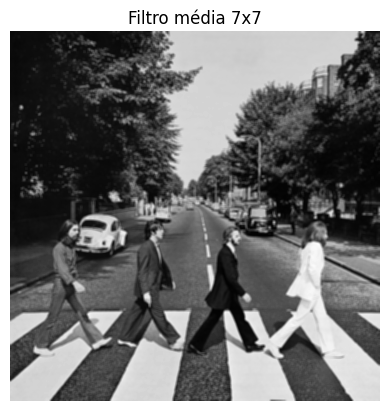

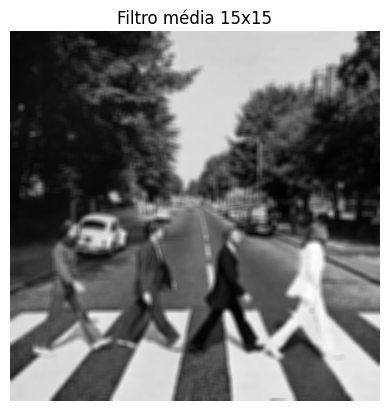

In [78]:
kernels = [3, 7, 15]

for k in kernels:
    kernel = criar_kernel_media(k)
    resultado = aplicar_convolucao(
        imagem_beatles,
        kernel,
        'reflect'
    )
    mostrar_imagem(
        resultado,
        f"Filtro média {k}x{k}"
    )

# Tarefa 4

### Implementação do kernel gaussiano:

In [79]:
def criar_kernel_gaussiano(tamanho, sigma):
    ax = np.linspace(
        -(tamanho // 2),
        tamanho // 2,
        tamanho
    )
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(
        -(xx**2 + yy**2)
        / (2 * sigma**2)
    )
    return normalizar_kernel(kernel)

### Resultados da aplicação

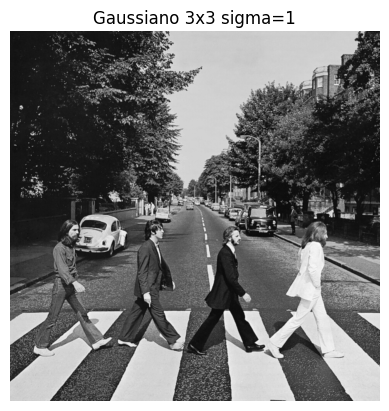

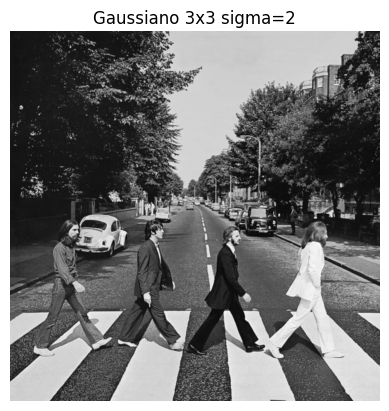

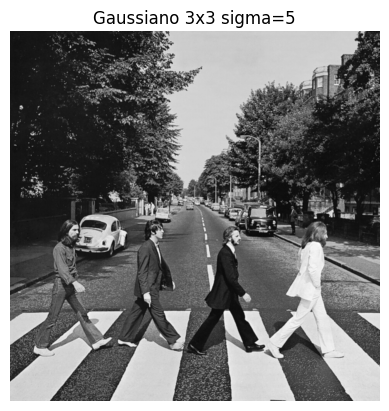

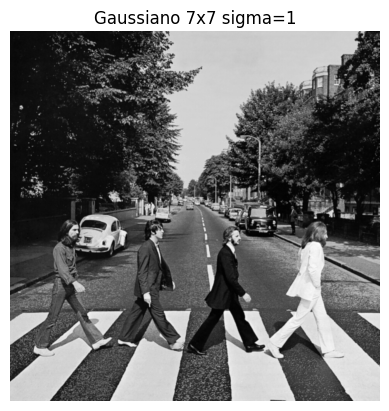

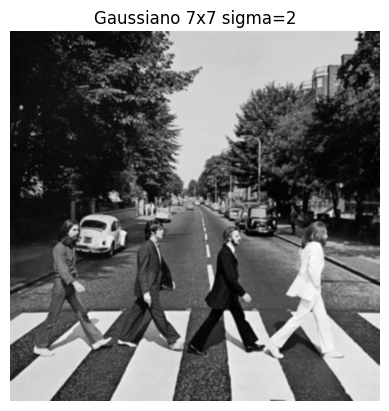

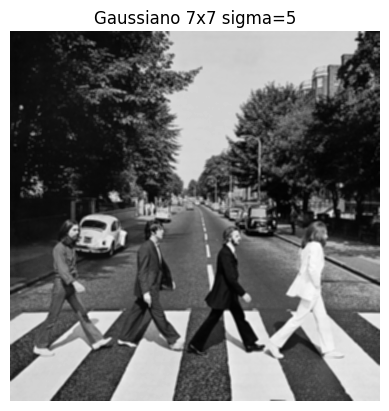

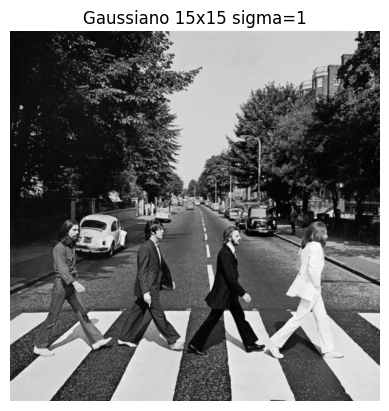

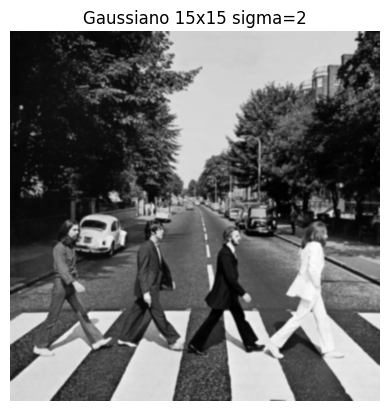

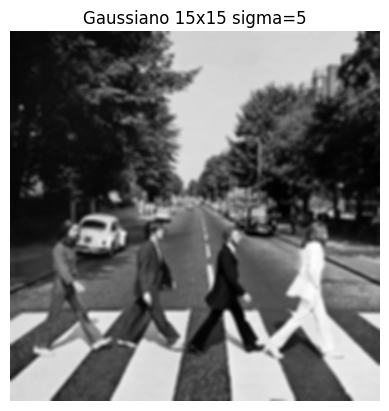

In [80]:
kernels = [3, 7, 15]
sigmas = [1, 2, 5]

for k in kernels:
    for s in sigmas:
        kernel = criar_kernel_gaussiano(
            k,
            s
        )
        resultado = aplicar_convolucao(
            imagem_beatles,
            kernel,
            'reflect'
        )
        mostrar_imagem(
            resultado,
            f"Gaussiano {k}x{k} sigma={s}"
        )

# Tarefa 5

### Implementação do detector de bordas:

In [84]:
def detectar_bordas(img):
    kernel = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ])

    resultado = aplicar_convolucao(img, kernel, 'reflect')
    resultado = np.abs(resultado)
    
    return normalizar_imagem(resultado)

### Resultado do detectod de bordas:

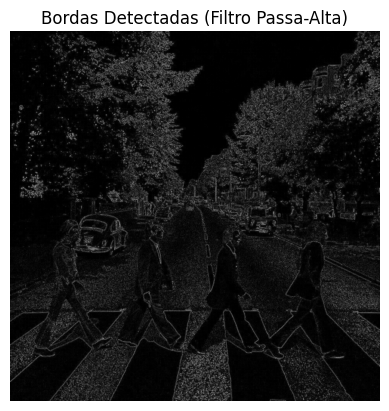

In [85]:
bordas = detectar_bordas(imagem_beatles)
mostrar_imagem(bordas, "Bordas Detectadas (Filtro Passa-Alta)")